# 04 — Training: Loop Design, Real Convergence Curves, Vision-LoRA Extension (Fase 3 + 5)

**Prerequisites to run this notebook:**
- `torch5050` conda env, CUDA GPU (RTX 5050, 8.5 GB) available.
- `Salesforce/blip-image-captioning-base` and `indolem/indobert-base-uncased` cached locally
  (`HF_HUB_DISABLE_XET=1`, `HF_HUB_OFFLINE=1` set below).
- `data/processed/captions_{train,val}.jsonl` present.
- Real training logs already on disk: `logs/full_run_v1_{epochs,steps}.jsonl`,
  `logs/full_run_v2_{epochs,steps}.jsonl`, `logs/full_run_v3_vision_{epochs,steps}.jsonl`,
  and matching `logs/*_run.json` summaries, `configs/*.json` hyperparameter snapshots.

**Scope.** This notebook does **not** retrain the reported models from scratch — each real run
took 1-2 hours on this GPU. Instead it (1) explains the real training-loop design implemented in
`scripts/train.py`, (2) loads and plots the REAL logged loss curves from the three actual runs,
and (3) runs a small number of REAL optimizer steps on a tiny real data subset purely as a
mechanics demonstration, clearly separated from and never confused with the reported results.

In [1]:
import os, sys, json, time
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")
os.environ.setdefault("HF_HUB_OFFLINE", "1")

ROOT = r"C:\Users\Wijdan\Documents\GEMASTIK\Data Mining"
sys.path.insert(0, ROOT)

import pandas as pd
import matplotlib.pyplot as plt

LOGS = os.path.join(ROOT, "logs")
CONFIGS = os.path.join(ROOT, "configs")
RUNS = ["full_run_v1", "full_run_v2", "full_run_v3_vision"]
RUN_LABELS = {
    "full_run_v1": "v1: text-only LoRA (from base)",
    "full_run_v2": "v2: text-only LoRA (continued from v1/best)",
    "full_run_v3_vision": "v3: text + vision LoRA (resumed from v2/best)",
}
print("imports OK")

imports OK


## 1. Training-loop design (`scripts/train.py`) — why it is built this way

**Two AdamW parameter groups, not one shared LR.** Every trainable parameter falls into exactly
two buckets (`build_param_groups()`, verified empirically via `named_parameters()`, not guessed):
LoRA adapter matrices, and the word-embedding matrix + LM-head bias. These are different in
*nature* — LoRA deltas are a small rank-8 correction on top of pretrained attention weights
(further scaled down internally by `alpha/r = 4`), whereas the embedding matrix is being
relearned close to from-scratch for 74.6% of its rows (Fase 2, `docs/design_decisions.md` §3/§6).
Standard practice for each, independently: LoRA is commonly trained at 1e-4-2e-4; full-parameter
embedding fine-tuning on a small (~7k example) corpus uses a lower LR (2e-5-5e-5) to avoid the
embedding matrix overfitting/drifting before the rest of the model can use it. The real runs use
`lr_lora=1e-4`, `lr_embed=5e-5` (see `configs/full_run_v2.json` below).

**Cosine schedule with warmup**, `bf16` autocast (native on the RTX 5050's Blackwell-class
tensor cores, no `GradScaler` needed unlike fp16), gradient accumulation (micro batch 4 x
grad_accum 4 = effective batch 16), gradient clipping at norm 1.0, early stopping on val_loss
(patience 3 epochs).

**Reproducibility contract enforced by `train.py`:** fixed seed (42) on every RNG before anything
else runs; a JSON config snapshot (all hyperparameters, argv, library versions, detected GPU,
seed) written to `configs/` **before** the first optimizer step; JSONL step/epoch logs written
*as training proceeds*, not reconstructed after the fact; checkpoints saved via
`save_trainable_state()` (never `model.save_pretrained()`, which would silently drop the
24.5M-param embedding matrix — risk #6 in `docs/design_decisions.md`).

**Vision-LoRA extension (Fase 5, `docs/design_decisions.md` §5.0-§5.3).** Fase 4 found the
text-only model biased toward "no visible damage" boilerplate (83.0% generated vs. 34.2%
reference) and weak `BENCANA` (disaster-type) accuracy (58.8%), with errors collapsing onto the
two most frequent training classes rather than scattering — the signature of a decoder leaning on
text-side statistics because the frozen vision tower gives it nothing decisive to distinguish
disaster types. `full_run_v3_vision` **resumes from `full_run_v2/best`** (not from scratch) and
adds LoRA on the vision tower's fused `self_attn.qkv` projection. This is safe because LoRA's
`lora_B` is zero-initialized: `dW = B @ A = 0` at load time, so the expanded model is numerically
**identical** to the checkpoint until training actually moves `B` — asserted, not assumed, by
`load_trainable_state(..., allow_new_lora_modules=True)` (§5.3).

In [2]:
configs = {}
for run in RUNS:
    with open(os.path.join(CONFIGS, f"{run}.json"), encoding="utf-8") as f:
        configs[run] = json.load(f)

hp_table = pd.DataFrame({
    run: {k: v for k, v in cfg["hyperparameters"].items()
          if k in ("epochs", "batch_size", "grad_accum", "lr_lora", "lr_embed",
                    "warmup_steps", "lora_r", "lora_alpha", "vision_lora", "resume_from", "amp")}
    for run, cfg in configs.items()
})
display(hp_table)

,full_run_v1,full_run_v2,full_run_v3_vision
epochs,10,10,10
batch_size,4,4,4
grad_accum,4,4,4
lr_lora,0.0001,0.0001,0.0001
lr_embed,0.00005,0.00005,0.00005
warmup_steps,200,200,200
lora_r,8,8,8
lora_alpha,32,32,32
amp,bf16,bf16,bf16
resume_from,None,checkpoints/full_run_v1/best,checkpoints/full_run_v2/best


## 2. Real per-step and per-epoch loss curves, all three runs

In [3]:
steps_df, epochs_df = {}, {}
for run in RUNS:
    with open(os.path.join(LOGS, f"{run}_steps.jsonl"), encoding="utf-8") as f:
        recs = [json.loads(l) for l in f]
    steps_df[run] = pd.DataFrame([r for r in recs if "loss" in r])  # drop partial-val-only rows
    with open(os.path.join(LOGS, f"{run}_epochs.jsonl"), encoding="utf-8") as f:
        epochs_df[run] = pd.DataFrame([json.loads(l) for l in f])

for run in RUNS:
    print(f"{run}: {len(steps_df[run])} step-log rows, {len(epochs_df[run])} epoch-log rows")

full_run_v1: 220 step-log rows, 10 epoch-log rows
full_run_v2: 218 step-log rows, 10 epoch-log rows
full_run_v3_vision: 218 step-log rows, 10 epoch-log rows


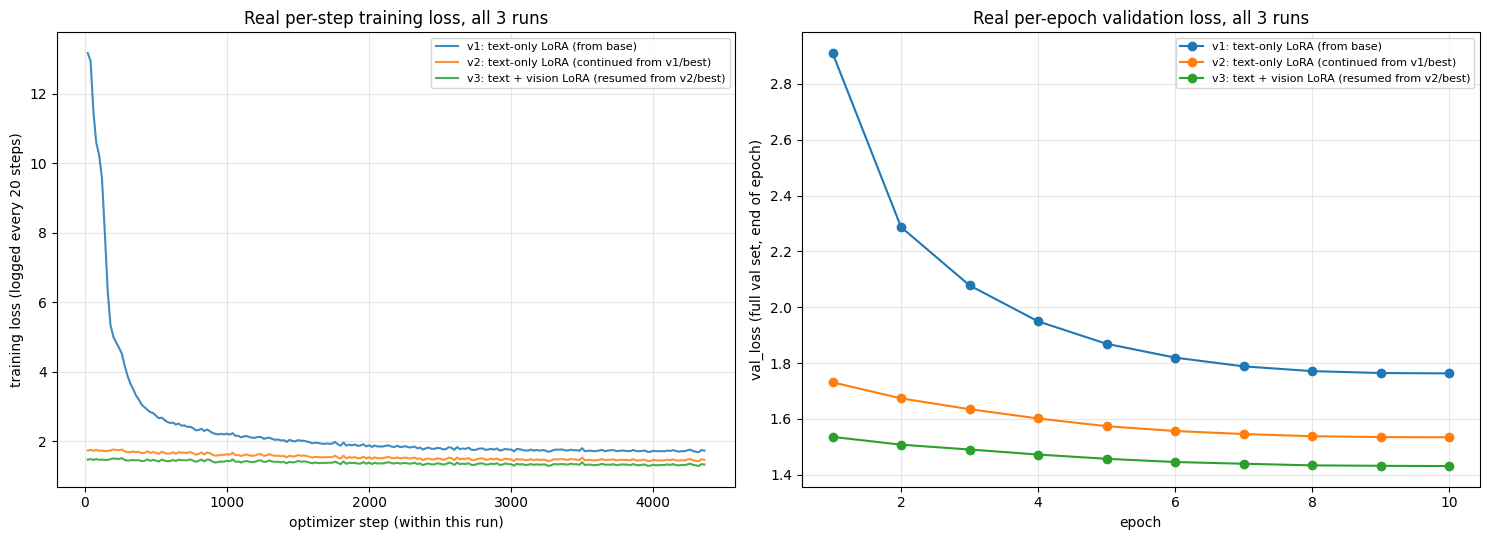

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for run in RUNS:
    axes[0].plot(steps_df[run]["step"], steps_df[run]["loss"], label=RUN_LABELS[run], alpha=0.85)
axes[0].set_xlabel("optimizer step (within this run)")
axes[0].set_ylabel("training loss (logged every 20 steps)")
axes[0].set_title("Real per-step training loss, all 3 runs")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

for run in RUNS:
    axes[1].plot(epochs_df[run]["epoch"], epochs_df[run]["val_loss"], marker="o", label=RUN_LABELS[run])
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("val_loss (full val set, end of epoch)")
axes[1].set_title("Real per-epoch validation loss, all 3 runs")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Convergence / plateau behavior, measured (not eyeballed)

`docs/design_decisions.md` §5.6 states the epoch 9->10 val_loss delta was ~15x smaller than the
epoch 6->7 delta for `full_run_v1 -> full_run_v2` continued training, and that `full_run_v3_vision`
also plateaus by its final epoch. Recomputed directly from the real logs below.

In [5]:
for run in RUNS:
    df = epochs_df[run].sort_values("epoch").reset_index(drop=True)
    deltas = df["val_loss"].diff()
    print(f"\n{run}:")
    print(f"  best val_loss: {df['val_loss'].min():.4f}  (epoch {df.loc[df['val_loss'].idxmin(), 'epoch']})")
    print(f"  final epoch-over-epoch delta (epoch {int(df['epoch'].iloc[-2])}->{int(df['epoch'].iloc[-1])}): "
          f"{deltas.iloc[-1]:+.4f}")
    if len(df) >= 3:
        print(f"  an earlier delta (epoch {int(df['epoch'].iloc[1])}->{int(df['epoch'].iloc[2])}): "
              f"{deltas.iloc[2]:+.4f}   (ratio final/earlier: "
              f"{abs(deltas.iloc[-1])/max(abs(deltas.iloc[2]), 1e-9):.3f})")


full_run_v1:
  best val_loss: 1.7632  (epoch 10)
  final epoch-over-epoch delta (epoch 9->10): -0.0012
  an earlier delta (epoch 2->3): -0.2087   (ratio final/earlier: 0.006)

full_run_v2:
  best val_loss: 1.5343  (epoch 10)
  final epoch-over-epoch delta (epoch 9->10): -0.0007
  an earlier delta (epoch 2->3): -0.0386   (ratio final/earlier: 0.019)

full_run_v3_vision:
  best val_loss: 1.4312  (epoch 10)
  final epoch-over-epoch delta (epoch 9->10): -0.0009
  an earlier delta (epoch 2->3): -0.0174   (ratio final/earlier: 0.051)


## 4. Real run summaries: wall-clock, peak GPU memory, final val_loss

Loaded from the real `logs/*_run.json` files written by `train.py` at the end of each run.

In [6]:
run_summaries = {}
for run in RUNS:
    with open(os.path.join(LOGS, f"{run}_run.json"), encoding="utf-8") as f:
        run_summaries[run] = json.load(f)

summary_df = pd.DataFrame({
    run: {
        "best_val_loss": s["best_val_loss"],
        "wall_clock_h": s["total_wall_clock_h"],
        "peak_gpu_mem_mb": s["peak_gpu_mem_mb"],
        "global_step": s["global_step"],
    }
    for run, s in run_summaries.items()
}).T
display(summary_df)

print("\nThis directly reproduces docs/design_decisions.md SS5.6's reported comparison: "
      "vision LoRA improved best val_loss "
      f"{run_summaries['full_run_v2']['best_val_loss']:.4f} -> "
      f"{run_summaries['full_run_v3_vision']['best_val_loss']:.4f} "
      f"at the cost of extra activation memory "
      f"({run_summaries['full_run_v2']['peak_gpu_mem_mb']:.0f} -> "
      f"{run_summaries['full_run_v3_vision']['peak_gpu_mem_mb']:.0f} MB).")

,best_val_loss,wall_clock_h,peak_gpu_mem_mb,global_step
full_run_v1,1.763158,1.386,3620.8,4370.0
full_run_v2,1.534265,1.400,3621.9,4370.0
full_run_v3_vision,1.431236,1.754,5483.0,4370.0



This directly reproduces docs/design_decisions.md SS5.6's reported comparison: vision LoRA improved best val_loss 1.5343 -> 1.4312 at the cost of extra activation memory (3622 -> 5483 MB).


## 5. Mechanics demo — REAL optimizer steps, NOT the reported run

**This section is a working demonstration of the training loop's mechanics only.** It builds the
real model via `build_model()`, runs a handful of real forward/backward/optimizer steps on a tiny
16-record real data subset, and prints the real (noisy, small-sample) loss values produced. **It
is not a reproduction of `full_run_v1/v2/v3_vision` and the numbers below must never be compared
against the logged curves in §2-§4 above** — those came from the full 6,999-record training set
run for many epochs; this is a few seconds of mechanics sanity-checking.

In [7]:
import torch
from torch.utils.data import DataLoader
from transformers import get_cosine_schedule_with_warmup

from scripts.build_model import build_model
from scripts.dataset import DisasterCaptionDataset, make_collate_fn
from scripts.train import build_param_groups, set_seed

set_seed(42)
demo_bundle = build_model(dtype=torch.float32, device="cuda", verbose=False)
demo_bundle.model.train()

demo_ds = DisasterCaptionDataset("train", bundle=demo_bundle, drop_unreadable=True, limit=16)
collate = make_collate_fn(demo_bundle.codec)
demo_loader = DataLoader(demo_ds, batch_size=2, shuffle=True, collate_fn=collate, num_workers=0,
                          generator=torch.Generator().manual_seed(42))

param_groups = build_param_groups(demo_bundle.model, lr_lora=1e-4, lr_embed=5e-5)
optimizer = torch.optim.AdamW(param_groups, weight_decay=0.01)
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=1, num_training_steps=8)

print("\n" + "=" * 70)
print("MECHANICS DEMO ONLY -- 8 real optimizer steps on a 16-record subset")
print("NOT the reported training run -- see SS2-SS4 above for the real logged results")
print("=" * 70 + "\n")

demo_losses = []
step = 0
t0 = time.time()
for batch in demo_loader:
    batch = {k: v.to("cuda") for k, v in batch.items()}
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        out = demo_bundle.model(pixel_values=batch["pixel_values"], input_ids=batch["input_ids"],
                                attention_mask=batch["attention_mask"], labels=batch["labels"])
    out.loss.backward()
    torch.nn.utils.clip_grad_norm_([p for g in param_groups for p in g["params"]], 1.0)
    optimizer.step(); scheduler.step(); optimizer.zero_grad(set_to_none=True)
    step += 1
    demo_losses.append(out.loss.item())
    print(f"  step {step}: loss={out.loss.item():.4f}  lr_lora={optimizer.param_groups[0]['lr']:.2e}  "
         f"lr_embed={optimizer.param_groups[1]['lr']:.2e}")
    if step >= 8:
        break

print(f"\n8 real steps completed in {time.time()-t0:.1f}s -- loop mechanics confirmed working "
      f"(forward, backward, both param groups stepping, cosine schedule advancing).")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


[param groups] lora: 96 tensors / 589,824 params @ lr=0.0001
[param groups] embed+bias: 2 tensors / 24,555,708 params @ lr=5e-05

MECHANICS DEMO ONLY -- 8 real optimizer steps on a 16-record subset
NOT the reported training run -- see SS2-SS4 above for the real logged results



  step 1: loss=13.2029  lr_lora=1.00e-04  lr_embed=5.00e-05


  step 2: loss=13.1598  lr_lora=9.50e-05  lr_embed=4.75e-05


...

  step 4: loss=13.0669  lr_lora=6.11e-05  lr_embed=3.06e-05


  step 5: loss=12.9682  lr_lora=3.89e-05  lr_embed=1.94e-05


  step 6: loss=12.8886  lr_lora=1.88e-05  lr_embed=9.41e-06


  step 7: loss=12.7690  lr_lora=4.95e-06  lr_embed=2.48e-06


  step 8: loss=12.4266  lr_lora=0.00e+00  lr_embed=0.00e+00

8 real steps completed in 4.1s -- loop mechanics confirmed working (forward, backward, both param groups stepping, cosine schedule advancing).


## Summary

The real per-step and per-epoch curves in §2 (loaded from `logs/full_run_v{1,2,3_vision}_*.jsonl`,
written live during the actual training runs) show text-only training plateauing across
`full_run_v1 -> full_run_v2`, and `full_run_v3_vision` converging to a lower val_loss than either
text-only run after the vision adapter is added — matching the narrative and numbers in
`docs/design_decisions.md` §5.6. §5's mechanics demo is a separate, clearly-labeled sanity check
of the training loop's code path and is not evidence about model quality.